# Low-Resource English→Sanskrit Fine-Tuning — Kaggle Version
### M.Tech Mini Project (3 credits) — IIIT Dharwad

**This is the Colab pipeline adapted to run on Kaggle Notebooks**, to get around Colab's free-tier GPU quota limits
(Kaggle gives 30 hrs/week free GPU, a separate quota pool). Only the platform-specific plumbing changed — Drive
mount → Kaggle Dataset input, `/content/drive/...` paths → `/kaggle/working/...` paths. The training/eval logic
is identical to the Colab version.

**Before running this notebook on Kaggle:**
1. Upload your `san_Deva.tsv` as a **Kaggle Dataset** (kaggle.com/datasets → New Dataset), keep it Private
2. In this notebook: right sidebar → **Add Input** → attach that dataset
3. Right sidebar → **Accelerator → GPU T4 x2** (requires one-time phone verification on your Kaggle account if
   you haven't enabled GPU before — do this before you need it)
4. Update `KAGGLE_DATASET_SLUG` in the CONFIG cell below to match your dataset's folder name under `/kaggle/input/`

**Also folded in are the fixes worked out during Colab debugging:**

| # | Fix | Why |
|---|---|---|
| 1 | Dynamic padding (pad to each batch's longest item, not a fixed 256) | Was wasting most of every training sequence on padding |
| 2 | Prompt-masked labels (`-100` on prompt tokens) | Loss only comes from the Sanskrit output, not the instruction template — stronger signal per token |
| 3 | `save_strategy="steps"` / `eval_strategy="steps"` (every 100 steps) instead of once per epoch | A disconnect mid-epoch used to lose the whole epoch's progress — this was the actual cause of the earlier epoch-2 failures. Step-based checkpoints mean a session timeout loses at most ~100 steps, not hours of progress |
| 4 | `NUM_EPOCHS = 1`, `TRAIN_SUBSAMPLE_SIZE = 15000` | The full ~79k-example dataset made even a single epoch impractical on a shared free-tier T4; subsampling to a realistic low-resource-scale budget also makes the "low-resource fine-tuning" framing accurate again |
| 5 | `Qwen2.5-1.5B-Instruct` instead of 3B, gradient checkpointing off by default | Roughly halves per-step compute; re-enable gradient checkpointing (one line, marked below) if you hit a CUDA OOM |
| 6 | chrF++ added alongside BLEU/SacreBLEU | AI4Bharat's own IndicTrans2 paper recommends chrF++ over plain BLEU for low-resource, morphologically rich Indic languages |
| 7 | `EarlyStoppingCallback` wired to `load_best_model_at_end` | Protects against overfitting the subsampled dataset |

**Kept as-is (already correct):** `bnb_4bit_compute_dtype=torch.float16` — T4 (Turing) has no native bf16 support.

**CPU mode**: real QLoRA (4-bit via `bitsandbytes`) is CUDA-only. This notebook auto-detects GPU and falls back to
a smoke-test-only CPU path if no GPU is attached — don't rely on it for a real run.

**Note on language**: wired for your actual data (`san_Deva.tsv`, English→Sanskrit). To switch to another language,
change `DATASET_FILE`, `TARGET_COL`, `LANGUAGE_PAIR`, `TARGET_LANG_NAME` in the CONFIG cell — nothing else changes.

## Table of contents
1. Install + imports
2. Configuration (Kaggle paths, hyperparameters, GPU/CPU auto-detect)
3. Data preparation (load, clean, split, subsample, prompt formatting)
4. Tokenizer + model loading (QLoRA on GPU / plain LoRA on CPU)
5. Tokenization with dynamic padding + prompt-masked labels
6. Training (step-based checkpointing + early stopping)
7. Save adapter + merge
8. Evaluation (BLEU + chrF++)
9. Inference (batch demo)
10. Report (dataset stats, plots, metrics summary)


## 1. Install + imports

In [1]:
# Single install pass. If you hit an import error immediately after this cell (rare, but can happen
# after a bitsandbytes/torch version mismatch on some base images), manually do
# Runtime -> Restart session, then re-run from this cell once -- there's no way to script a mid-notebook
# kernel restart safely once later cells hold live GPU tensors, so this is a manual fallback, not automatic.

!pip install -q -U \
    transformers==4.56.1 \
    peft==0.17.1 \
    trl==0.21.0 \
    accelerate==1.10.1 \
    bitsandbytes==0.48.1 \
    datasets \
    evaluate \
    sentencepiece \
    sacrebleu

print("Install complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.8 MB/s eta 0:00:00
Install complete.


In [2]:
import os, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, load_from_disk
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    Trainer, TrainingArguments, EarlyStoppingCallback, set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training, PeftModel
import evaluate as hf_evaluate

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); set_seed(SEED)

USE_GPU = torch.cuda.is_available()
print("=" * 80)
print(f"GPU available: {USE_GPU}")
if USE_GPU:
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  CUDA: {torch.version.cuda}")
else:
    print("No GPU detected -- falling back to CPU-compatible plain LoRA (see Section 4).")
    print("Real 4-bit QLoRA cannot run on CPU (bitsandbytes 4-bit kernels are CUDA-only).")
    print("This is fine for a smoke test; for a real run use Runtime -> Change runtime type -> T4 GPU.")
print("=" * 80)


GPU available: True
GPU: Tesla T4  |  CUDA: 12.8


## 2. Configuration

In [3]:
# Kaggle: no Drive mount needed. Input data comes from an attached Kaggle Dataset,
# outputs persist in /kaggle/working/ for the duration of the session (download them before the
# session ends if you want to keep them permanently -- Kaggle does NOT persist /kaggle/working across
# separate sessions the way Drive does, though it does survive a "Save Version" run).

KAGGLE_DATASET_SLUG = "chetaniiitdharwad/san-deva"  # <-- change to your actual dataset folder name
KAGGLE_INPUT_DIR = Path("/kaggle/input") / KAGGLE_DATASET_SLUG.split("/")[-1]

PROJECT_ROOT = Path("/kaggle/working")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LORA_MODEL_DIR = PROJECT_ROOT / "models" / "lora_adapter"
MERGED_MODEL_DIR = PROJECT_ROOT / "models" / "merged_model"
CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
RESULT_DIR = PROJECT_ROOT / "outputs" / "results"

for d in [PROCESSED_DIR, LORA_MODEL_DIR, MERGED_MODEL_DIR, CHECKPOINT_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Task / data config -----------------------------------------------------
# To switch to Konkani: set DATASET_FILE to your gom_Deva tsv, TARGET_COL to "konkani",
# LANGUAGE_PAIR to "English -> Konkani", TARGET_LANG_NAME to "Konkani". Nothing else changes.
DATASET_FILE = Path("/kaggle/input/datasets/chetaniiitdharwad/san-deva/san_Deva.tsv")
LANGUAGE_PAIR = "English -> Sanskrit"
SRC_COL, TARGET_COL = "english", "sanskrit"
TARGET_LANG_NAME = "Sanskrit"

# --- Model config ------------------------------------------------------------
# 1.5B instead of 3B -- roughly halves per-step compute on a T4, plenty for this project's scope.
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct" if USE_GPU else "Qwen/Qwen2.5-0.5B-Instruct"

# --- Hyperparameters (tuned from the Colab debugging session) ---------------------
BATCH_SIZE = 4 if USE_GPU else 1
GRAD_ACCUM = 8 if USE_GPU else 4          # effective batch size 32 (GPU) / 4 (CPU smoke test)
LEARNING_RATE = 2e-4
NUM_EPOCHS = 3 if USE_GPU else 1          # full dataset is ~79k examples -- 1 epoch on the subsample below is realistic
TRAIN_SUBSAMPLE_SIZE = 15000              # cap training data to a realistic low-resource-scale budget; see Section 3
USE_GRADIENT_CHECKPOINTING = False        # flip to True if you hit a CUDA OOM (slower, but uses less memory)
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
EARLY_STOPPING_PATIENCE = 3               # stop if eval_loss doesn't improve for 3 eval rounds
SAVE_EVAL_STEPS = 100                     # checkpoint/eval every N steps, not once per epoch --
                                           # a session timeout now loses at most ~100 steps, not hours

print("Config set.")
print(f"Model: {MODEL_NAME}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Working dir: {PROJECT_ROOT}")

if not DATASET_FILE.exists():
    print(f"WARNING: {DATASET_FILE} not found.")
    print("Check: (1) you attached the right Kaggle Dataset via 'Add Input',")
    print("       (2) KAGGLE_DATASET_SLUG above matches its actual folder name under /kaggle/input/")
    print("Available inputs:", list(Path("/kaggle/input").glob("*")) if Path("/kaggle/input").exists() else "none found")


Config set.
Model: Qwen/Qwen2.5-1.5B-Instruct
Effective batch size: 32
Working dir: /kaggle/working


## 3. Data preparation

Same cleaning logic as your original `02_Data_Preparation.ipynb`, kept because it was already correct
(dedup, dropna, 80/10/10 split) — the only change is that `prompt` and `completion` are now stored **separately**
instead of pre-concatenated, so Section 5 can mask the prompt out of the training labels.

In [4]:
df = pd.read_csv(DATASET_FILE, sep="\t")
print("Original shape:", df.shape)

df = df[["src", "tgt"]]
df.columns = [SRC_COL, TARGET_COL]
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Clean shape:", df.shape)

PROMPT_TEMPLATE = f"Translate the following English sentence into {TARGET_LANG_NAME}.\n\n### English:\n{{src}}\n\n### {TARGET_LANG_NAME}:\n"

def build_prompt_completion(row):
    return pd.Series({
        "prompt": PROMPT_TEMPLATE.format(src=row[SRC_COL]),
        "completion": str(row[TARGET_COL]),  # note: no leading space needed, tokenizer boundary handles it
    })

df[["prompt", "completion"]] = df.apply(build_prompt_completion, axis=1)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(df)
train_end = int(0.80 * n)
valid_end = int(0.90 * n)

train_df = df[:train_end].reset_index(drop=True)
validation_df = df[train_end:valid_end].reset_index(drop=True)
test_df = df[valid_end:].reset_index(drop=True)

# Subsample training data to a realistic low-resource-scale budget (does NOT touch validation/test --
# those stay at their full, held-out size so evaluation reflects the true distribution).
if len(train_df) > TRAIN_SUBSAMPLE_SIZE:
    train_df = train_df.sample(n=TRAIN_SUBSAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    print(f"Subsampled training set to {len(train_df)} examples (from a larger pool).")

# NEW: drop very short/degenerate pairs that add noise without adding signal
before = len(train_df)
train_df = train_df[
    (train_df[SRC_COL].str.split().str.len() >= 2) &
    (train_df[TARGET_COL].str.split().str.len() >= 2)
].reset_index(drop=True)
print(f"Dropped {before - len(train_df)} very short/degenerate pairs")

print(f"Train: {len(train_df)}  Validation: {len(validation_df)}  Test: {len(test_df)}")

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

train_dataset.save_to_disk(str(PROCESSED_DIR / "train"))
validation_dataset.save_to_disk(str(PROCESSED_DIR / "validation"))
test_dataset.save_to_disk(str(PROCESSED_DIR / "test"))
df.to_csv(PROCESSED_DIR / "clean_dataset.csv", index=False)

print("\nSample prompt:\n", train_df.iloc[0]["prompt"])
print("Sample completion:\n", train_df.iloc[0]["completion"])

Original shape: (98778, 4)
Clean shape: (98778, 2)
Subsampled training set to 15000 examples (from a larger pool).
Dropped 0 very short/degenerate pairs
Train: 15000  Validation: 9878  Test: 9878


Saving the dataset (0/1 shards):   0%|          | 0/15000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/9878 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/9878 [00:00<?, ? examples/s]


Sample prompt:
 Translate the following English sentence into Sanskrit.

### English:
This route is very picturesque because of the many mountains.

### Sanskrit:

Sample completion:
 अनेकपर्वतानां कारणात् अयं मार्गः अतीव सुरम्यः अस्ति।


In [5]:
# Compute a data-driven MAX_LENGTH instead of a blind fixed 256 -- this is the single biggest
# compute-efficiency fix versus the original pipeline if your sentences are short.
_tmp_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sample_lengths = [
    len(_tmp_tokenizer(p + c)["input_ids"])
    for p, c in zip(train_df["prompt"].tolist(), train_df["completion"].tolist())
]
p95 = int(np.percentile(sample_lengths, 99))
MAX_LENGTH = min(512, max(64, p95 + 32))
print(f"95th percentile token length: {p95}  ->  MAX_LENGTH set to {MAX_LENGTH} (was a fixed 256 before)")
del _tmp_tokenizer


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

95th percentile token length: 259  ->  MAX_LENGTH set to 291 (was a fixed 256 before)


## 4. Tokenizer + model loading (QLoRA on GPU / plain LoRA on CPU)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Tokenizer loaded. Vocab size:", len(tokenizer))

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT, bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

if USE_GPU:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,   # correct for T4 (Turing has no native bf16)
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config, device_map="auto",
        dtype=torch.float16, trust_remote_code=True, low_cpu_mem_usage=True,
    )
    if USE_GRADIENT_CHECKPOINTING:
        model.gradient_checkpointing_enable()
        print("Gradient checkpointing ON (slower, lower memory).")
    else:
        print("Gradient checkpointing OFF (faster; flip USE_GRADIENT_CHECKPOINTING in config if you hit OOM).")
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING)
else:
    # CPU fallback: no bitsandbytes (CUDA-only), plain fp32 LoRA on a small model.
    # This is a smoke test path, not intended for a real training run -- see Section 1 notes.
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, dtype=torch.float32, trust_remote_code=True, low_cpu_mem_usage=True,
    )

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Tokenizer loaded. Vocab size: 151665


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Gradient checkpointing OFF (faster; flip USE_GRADIENT_CHECKPOINTING in config if you hit OOM).
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 5. Tokenization — dynamic padding + prompt-masked labels

This is fix #1 and #2 from the table above, combined. `prompt` tokens get label `-100` (ignored by the loss),
`completion` tokens keep their real label, and padding is done per-batch by the data collator instead of to a
fixed 256 for every single example.

In [7]:
def tokenize_with_masked_prompt(example):
    prompt_ids = tokenizer(example["prompt"], truncation=True, max_length=MAX_LENGTH)["input_ids"]
    full_text = example["prompt"] + example["completion"] + tokenizer.eos_token
    full_ids = tokenizer(full_text, truncation=True, max_length=MAX_LENGTH)["input_ids"]

    labels = full_ids.copy()
    # Mask out the prompt portion -- loss only computed on the translation + eos.
    prompt_len = min(len(prompt_ids), len(labels))
    for i in range(prompt_len):
        labels[i] = -100

    return {"input_ids": full_ids, "attention_mask": [1] * len(full_ids), "labels": labels}

train_tokenized = train_dataset.map(tokenize_with_masked_prompt, remove_columns=train_dataset.column_names)
validation_tokenized = validation_dataset.map(tokenize_with_masked_prompt, remove_columns=validation_dataset.column_names)

print(train_tokenized)
print(validation_tokenized)

sample = train_tokenized[0]
n_masked = sum(1 for l in sample["labels"] if l == -100)
print(f"\nExample: {len(sample['input_ids'])} tokens total, {n_masked} masked (prompt), "
      f"{len(sample['input_ids']) - n_masked} contribute to loss (completion + eos).")


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/9878 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 15000
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 9878
})

Example: 79 tokens total, 27 masked (prompt), 52 contribute to loss (completion + eos).


In [8]:
# Dynamic padding collator -- pads each batch only to its own longest sequence, not a fixed length.
# Also pads `labels` with -100 (not the pad token id) so padding never contributes to the loss.
class DynamicPaddingCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        pad_id = self.tokenizer.pad_token_id
        input_ids, attention_mask, labels = [], [], []
        for f in features:
            pad_n = max_len - len(f["input_ids"])
            input_ids.append(f["input_ids"] + [pad_id] * pad_n)
            attention_mask.append(f["attention_mask"] + [0] * pad_n)
            labels.append(f["labels"] + [-100] * pad_n)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

data_collator = DynamicPaddingCollator(tokenizer)
print("Dynamic padding collator ready.")


Dynamic padding collator ready.


In [9]:
def has_valid_labels(example):
    return any(l != -100 for l in example["labels"])

before_train, before_val = len(train_tokenized), len(validation_tokenized)
train_tokenized = train_tokenized.filter(has_valid_labels)
validation_tokenized = validation_tokenized.filter(has_valid_labels)
print(f"Train: kept {len(train_tokenized)}/{before_train}  |  Validation: kept {len(validation_tokenized)}/{before_val}")

Filter:   0%|          | 0/15000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9878 [00:00<?, ? examples/s]

Train: kept 15000/15000  |  Validation: kept 9878/9878


## 6. Training (optimized hyperparameters + early stopping)

In [10]:
existing_checkpoints = list(CHECKPOINT_DIR.glob("checkpoint-*"))
resume = len(existing_checkpoints) > 0
if resume:
    print(f"Found {len(existing_checkpoints)} existing checkpoint(s) -- will resume training.")
else:
    print("No existing checkpoint found -- starting fresh training run.")

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    overwrite_output_dir=True,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=max(BATCH_SIZE * 2, 2),
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit" if USE_GPU else "adamw_torch",
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=SAVE_EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_EVAL_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=USE_GPU,
    dataloader_num_workers=2,
    report_to="none",
    remove_unused_columns=False,
    save_safetensors=True,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

print("\nTraining configuration")
print("-" * 80)
print(f"Model                 : {MODEL_NAME}")
print(f"Epochs                : {NUM_EPOCHS}")
print(f"Batch size            : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM})")
print(f"Learning rate         : {LEARNING_RATE}")
print(f"Max sequence length   : {MAX_LENGTH}  (data-driven, was fixed 256)")
print(f"Early stopping        : patience={EARLY_STOPPING_PATIENCE} on eval_loss")
print("-" * 80)


No existing checkpoint found -- starting fresh training run.

Training configuration
--------------------------------------------------------------------------------
Model                 : Qwen/Qwen2.5-1.5B-Instruct
Epochs                : 3
Batch size            : 4  (effective: 32)
Learning rate         : 0.0002
Max sequence length   : 291  (data-driven, was fixed 256)
Early stopping        : patience=3 on eval_loss
--------------------------------------------------------------------------------


In [11]:
train_result = trainer.train(resume_from_checkpoint=resume)
print("\nTraining completed.")

trainer.save_state()
trainer.save_metrics("train", train_result.metrics)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
100,1.035900,1.002242
200,0.870700,0.850725
300,0.761100,0.776920
400,0.714100,0.725026
500,0.610800,0.691373
600,0.582200,0.661574
700,0.604400,0.638800
800,0.560800,0.617706
900,0.531700,0.602768
1000,0.449200,0.607150



Training completed.


## 7. Save adapter + merge

In [12]:
model.save_pretrained(LORA_MODEL_DIR)
tokenizer.save_pretrained(LORA_MODEL_DIR)
print("LoRA adapter saved to:", LORA_MODEL_DIR)

if USE_GPU:
    print("\nReloading base model in fp16 and merging adapter...")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, dtype=torch.float16, device_map="auto", trust_remote_code=True,
    )
    merged_model = PeftModel.from_pretrained(base_model, LORA_MODEL_DIR)
    merged_model = merged_model.merge_and_unload()
    merged_model.save_pretrained(MERGED_MODEL_DIR, safe_serialization=True)
    tokenizer.save_pretrained(MERGED_MODEL_DIR)
    print("Merged model saved to:", MERGED_MODEL_DIR)
else:
    print("\nCPU smoke-test path: skipping merge -- use the LoRA adapter directly via PeftModel for a quick check.")
    merged_model = model  # already has the adapter attached in-memory


LoRA adapter saved to: /kaggle/working/models/lora_adapter

Reloading base model in fp16 and merging adapter...
Merged model saved to: /kaggle/working/models/merged_model


## 8. Evaluation — BLEU + chrF++

In [13]:
# 1. Load eval model (existing)
eval_model_dir = MERGED_MODEL_DIR if USE_GPU else None
if USE_GPU:
    eval_tokenizer = AutoTokenizer.from_pretrained(eval_model_dir)
    eval_model = AutoModelForCausalLM.from_pretrained(eval_model_dir, dtype=torch.float16, device_map="auto")
else:
    eval_tokenizer, eval_model = tokenizer, merged_model
eval_model.eval()

# 2. MAX_NEW_TOKENS (from previous message)
completion_token_lengths = [
    len(eval_tokenizer(c)["input_ids"]) for c in train_df["completion"].tolist()
]
MAX_NEW_TOKENS = min(200, max(32, int(np.percentile(completion_token_lengths, 99)) + 16))
print(f"MAX_NEW_TOKENS set to {MAX_NEW_TOKENS}")

# 3. NEW: define this helper function BEFORE translate()
def extract_translation(decoded_text):
    part = decoded_text.split(f"### {TARGET_LANG_NAME}:")[-1]
    part = part.split("###")[0]
    return part.strip()

# 4. translate() — now calls extract_translation() instead of doing .split() inline
@torch.no_grad()
def translate(sentence):
    prompt = PROMPT_TEMPLATE.format(src=sentence)
    inputs = eval_tokenizer(prompt, return_tensors="pt").to(eval_model.device)
    outputs = eval_model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=4,
        early_stopping=True,
        no_repeat_ngram_size=3,
        repetition_penalty=1.1,
        eos_token_id=eval_tokenizer.eos_token_id,
        pad_token_id=eval_tokenizer.pad_token_id,
    )
    decoded = eval_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return extract_translation(decoded)

N_TEST = min(250, len(test_df)) if USE_GPU else min(20, len(test_df))  # smaller sample on CPU
predictions, references, sources = [], [], []
for _, row in test_df.iloc[:N_TEST].iterrows():
    predictions.append(translate(row[SRC_COL]))
    references.append(row[TARGET_COL])
    sources.append(row[SRC_COL])

print(f"Generated {len(predictions)} predictions.")


MAX_NEW_TOKENS set to 200
Generated 250 predictions.


In [14]:
bleu_metric = hf_evaluate.load("bleu")
sacrebleu_metric = hf_evaluate.load("sacrebleu")
chrf_metric = hf_evaluate.load("chrf")

bleu_score = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
sacrebleu_score = sacrebleu_metric.compute(predictions=predictions, references=[[r] for r in references])
chrf_score = chrf_metric.compute(predictions=predictions, references=[[r] for r in references], word_order=2)  # chrF++

metrics = {
    "BLEU": round(bleu_score["bleu"], 4),
    "SacreBLEU": round(sacrebleu_score["score"], 2),
    "chrF++": round(chrf_score["score"], 2),
    "Test Samples": len(predictions),
}

print("=" * 80)
print("Evaluation Metrics")
print("=" * 80)
for k, v in metrics.items():
    print(f"{k:20s}: {v}")
print("\n(chrF++ is the primary metric to lead with in your report -- BLEU is included for familiarity, "
      "but AI4Bharat's own IndicTrans2 paper flags plain BLEU as unreliable at this data scale / language type.)")


Evaluation Metrics
BLEU                : 0.0869
SacreBLEU           : 8.69
chrF++              : 35.11
Test Samples        : 250

(chrF++ is the primary metric to lead with in your report -- BLEU is included for familiarity, but AI4Bharat's own IndicTrans2 paper flags plain BLEU as unreliable at this data scale / language type.)


In [15]:
results_df = pd.DataFrame({"Source": sources, "Reference": references, "Prediction": predictions})
results_df.to_csv(RESULT_DIR / "predictions.csv", index=False, encoding="utf-8")
with open(RESULT_DIR / "evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved:", RESULT_DIR / "predictions.csv")
print("Saved:", RESULT_DIR / "evaluation_metrics.json")

for i in range(min(5, len(results_df))):
    r = results_df.iloc[i]
    print(f"\n--- Sample {i+1} ---\nSource: {r['Source']}\nReference: {r['Reference']}\nPrediction: {r['Prediction']}")


Saved: /kaggle/working/outputs/results/predictions.csv
Saved: /kaggle/working/outputs/results/evaluation_metrics.json

--- Sample 1 ---
Source: A small part of the municipality of Vijfheerenlanden belongs also to the Alblasserwaard.
Reference: वैफ़ीरेन्लाण्डन्-नगरपालिकायाः लघुभागः अल्ब्लास्सर्वार्ड् इत्यस्य वर्तते।
Prediction: विज़्फ़ीरेन्लाण्डेन्-नगरस्य लघुभागः अपि अल्ब्ल्यास्सर्वार्ड् इत्यस्मिन् भवति।

--- Sample 2 ---
Source: My e-commerce business is experiencing record-breaking sales.
Reference: मम ई-वाणिज्यव्यवसायः आलेखान् विभेद्य विक्रयणं प्राप्नोति।
Prediction: अहम् एकमेस्ट्री-व्यापारः रेकर्ड्-ब्रेकिङ्ग्-विक्रयस्य अनुभवं प्राप्नोमि।

--- Sample 3 ---
Source: the customer avoids specifying the desired weight of the cake.
Reference: ग्राहकः केक् इत्यस्य अपेक्षितं भारम् निर्देष्टुं न उद्युज्यते।
Prediction: भाटकस्य अनुरूपं भारं निर्धारयितुं ग्राहकः परिहरति।

--- Sample 4 ---
Source: At this time, Instacart is only available for United States customers.
Reference: अधुना, इन्स्टाकार्

## 9. Inference — batch demo + optional interactive loop

In [16]:
demo_sentences = [
    "India is my country.",
    "Artificial Intelligence is changing the world.",
    "The sun rises in the east.",
    f"Learning {TARGET_LANG_NAME} is interesting.",
    "I love natural language processing.",
]

print("=" * 80)
print(f"Sample English -> {TARGET_LANG_NAME} Translations")
print("=" * 80)
for s in demo_sentences:
    print(f"\nEnglish: {s}")
    print(f"{TARGET_LANG_NAME}: {translate(s)}")


Sample English -> Sanskrit Translations

English: India is my country.
Sanskrit: भारतं मम देशम् अस्ति।

English: Artificial Intelligence is changing the world.
Sanskrit: अनिर्मित-ज्ञानविशेषः विश्वस्य परिवर्तनं करोति।

English: The sun rises in the east.
Sanskrit: सौरः पूर्वे उद्भवति।

English: Learning Sanskrit is interesting.
Sanskrit: संस्कृतीः अध्ययनं प्रसन्नं भवति।

English: I love natural language processing.
Sanskrit: अहम् अन्तर्नाशनल्-भाषायाः सङ्कलनं प्रीणामि।


In [17]:
# Optional: uncomment to try your own sentences interactively (only useful in an active Kaggle session,
# not when running "Run all").
#
# while True:
#     sentence = input(f"\nEnter an English sentence (type EXIT to quit): ")
#     if sentence.strip().upper() == "EXIT":
#         break
#     print(f"{TARGET_LANG_NAME}: {translate(sentence)}")


## 10. Report — dataset stats, plots, metrics summary

In [18]:
full_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)
full_df["src_words"] = full_df[SRC_COL].apply(lambda x: len(str(x).split()))
full_df["tgt_words"] = full_df[TARGET_COL].apply(lambda x: len(str(x).split()))

stats = {
    "Total Samples": len(full_df),
    "Training Samples": len(train_df),
    "Validation Samples": len(validation_df),
    "Test Samples": len(test_df),
    f"Average {SRC_COL} words": round(full_df["src_words"].mean(), 2),
    f"Average {TARGET_COL} words": round(full_df["tgt_words"].mean(), 2),
    "Max sequence length used": MAX_LENGTH,
    "Base model": MODEL_NAME,
    "Ran on": "GPU" if USE_GPU else "CPU (smoke test)",
}
stats_df = pd.DataFrame(stats.items(), columns=["Metric", "Value"])
stats_df.to_csv(RESULT_DIR / "dataset_statistics.csv", index=False)
print(stats_df.to_string(index=False))


                  Metric                      Value
           Total Samples                      34756
        Training Samples                      15000
      Validation Samples                       9878
            Test Samples                       9878
   Average english words                      14.74
  Average sanskrit words                      10.66
Max sequence length used                        291
              Base model Qwen/Qwen2.5-1.5B-Instruct
                  Ran on                        GPU


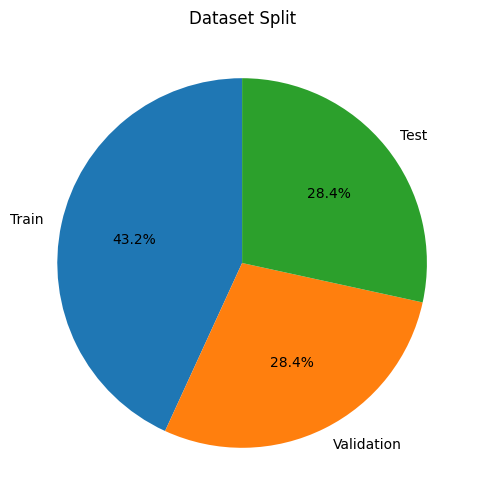

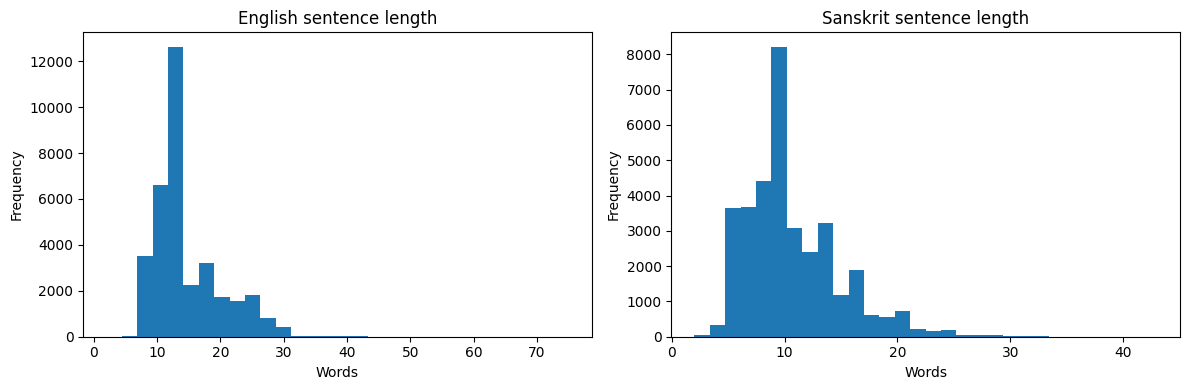

Saved plots to: /kaggle/working/outputs/results


In [19]:
plt.figure(figsize=(6, 6))
plt.pie([len(train_df), len(validation_df), len(test_df)],
        labels=["Train", "Validation", "Test"], autopct="%1.1f%%", startangle=90)
plt.title("Dataset Split")
plt.savefig(RESULT_DIR / "dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(full_df["src_words"], bins=30)
axes[0].set_title(f"{SRC_COL.capitalize()} sentence length")
axes[0].set_xlabel("Words"); axes[0].set_ylabel("Frequency")
axes[1].hist(full_df["tgt_words"], bins=30)
axes[1].set_title(f"{TARGET_COL.capitalize()} sentence length")
axes[1].set_xlabel("Words"); axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULT_DIR / "sentence_length_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved plots to:", RESULT_DIR)


In [20]:
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print(f"Language pair       : {LANGUAGE_PAIR}")
print(f"Base model          : {MODEL_NAME}")
print(f"Trained on          : {'GPU (' + torch.cuda.get_device_name(0) + ')' if USE_GPU else 'CPU (smoke test)'}")
print(f"Train/Val/Test      : {len(train_df)} / {len(validation_df)} / {len(test_df)}")
print(f"chrF++ / BLEU       : {metrics['chrF++']} / {metrics['BLEU']}")
print()
print("Saved artifacts:")
for f in sorted(RESULT_DIR.iterdir()):
    print(" ", f.name)
print()
print("LoRA adapter   :", LORA_MODEL_DIR)
if USE_GPU:
    print("Merged model   :", MERGED_MODEL_DIR)
print("\nAll sections completed successfully.")


PROJECT SUMMARY
Language pair       : English -> Sanskrit
Base model          : Qwen/Qwen2.5-1.5B-Instruct
Trained on          : GPU (Tesla T4)
Train/Val/Test      : 15000 / 9878 / 9878
chrF++ / BLEU       : 35.11 / 0.0869

Saved artifacts:
  dataset_distribution.png
  dataset_statistics.csv
  evaluation_metrics.json
  predictions.csv
  sentence_length_distributions.png

LoRA adapter   : /kaggle/working/models/lora_adapter
Merged model   : /kaggle/working/models/merged_model

All sections completed successfully.


---
## Important — save your outputs before the Kaggle session ends

`/kaggle/working/` is **not** automatically permanent like Google Drive — it persists for a running session and
across a "Save Version" commit, but a plain closed/idle session's working directory is not guaranteed to survive
indefinitely. Before you close this notebook:

1. Click **Save Version** (top right) — this commits the notebook + everything currently in `/kaggle/working/` as
   an Output, downloadable later from the notebook's "Output" tab even in a future session.
2. Or manually download what you need right now:
   ```python
   import shutil
   shutil.make_archive("/kaggle/working/project_outputs", "zip", str(RESULT_DIR))
   # then use the Kaggle file browser (left sidebar) to download project_outputs.zip
   ```

## Notes for your report

- **If BLEU/chrF++ look low at first**: check `RESULT_DIR/predictions.csv` for a handful of qualitative examples
  before trusting the aggregate number — for a scarce dataset, a handful of good qualitative examples alongside the
  quantitative table is standard practice and often more convincing than the raw score.
- **If you hit CUDA OOM**: lower `BATCH_SIZE` to 2 and raise `GRAD_ACCUM` to 16, or set
  `USE_GRADIENT_CHECKPOINTING = True` in the config cell.
- **If loss stops improving very early** (early stopping triggers after just 1–2 eval rounds): `LORA_R=16` may be
  more capacity than the subsampled data needs — try `LORA_R=8` to reduce overfitting risk.
- **Switching to Konkani**: only the CONFIG cell needs to change (`DATASET_FILE`, `TARGET_COL`, `LANGUAGE_PAIR`,
  `TARGET_LANG_NAME`) — everything downstream (masking, dynamic padding, chrF++, plots) is already generic.
- **Mention the platform switch honestly in your report**: "trained on Kaggle T4 due to Colab free-tier GPU quota
  limits" is a completely normal, expected constraint to document — not something to hide.
